# Imports and Libraries

## Installs

Dataset and code for downloading found:
https://huggingface.co/docs/datasets/v1.13.2/load_hub.html

In [1]:
# Commented out to stop multiple runs when running entire notebook
#%pip install -U datasets

In [2]:
# Commented out to stop multiple runs when running entire notebook
# Used to fix AcceleratorError: CUDA error
%pip install -U TabPFN
#pip install --upgrade unsloth unsloth_zoo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 732.3/732.3 kB 17.1 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


## Imports

`load_dataset` - For downloading sst2 dataset

`DatasetDict` - For creating project dataset splits

`pd` - For usage of DataFrame type

`AutoTokenizer` - For tokenisation of datasets required for transformer based models

`np` - Used in evaluation metrics for finding highest model output score

`accuracy_score` - Used to calculate overall accuracy of model

`precision_recall_fscore_support` - Used to calculate precision, recall, F1 and support of model

`AutoModelForSequenceClassification` - Used to load tansformer model for classification tasks

`DataCollatorWithPadding` - Used for padding training batches

`TrainingArguments` - Sets training arguments for model during training

`Trainer` - Joins together model arguments, model, datasets, collator, metrics, etc. to train model

`plt` - Used to plot model results

`random` - Used when creating noise 

`` - 

`` - 



In [3]:
from datasets import load_dataset, DatasetDict
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import random

# Defining which Model

In [4]:
# Defining which model.
model_name = "distilbert-base-uncased"

# Dataset

`dataframe_check` function:

- Takes:
  - `dataframe`: a dataFrame containing training, validation and testing data


This function performs a couple of manual checks on the dataset for inspection by the user. For example, printing the first few values and checking the balance

In [5]:
def dataframe_check(dataframe):
    # Check first couple values
    print("Dataframe head:")
    print(dataframe.head())
    print("\n-----------------------------------")
    print("\nBalance of dataset")
    print(dataframe["label"].value_counts())
    print(dataframe["label"].value_counts(normalize=True))

Load the sst2 dataset.

In [6]:
sst2 = load_dataset("glue", "sst2")

README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Convert to a dataframe and call the `dataframe_check` function to print some infomation about the training data

In [7]:
train_df = pd.DataFrame(sst2["train"])
dataframe_check(train_df)

Dataframe head:
                                            sentence  label  idx
0       hide new secretions from the parental units       0    0
1               contains no wit , only labored gags       0    1
2  that loves its characters and communicates som...      1    2
3  remains utterly satisfied to remain the same t...      0    3
4  on the worst revenge-of-the-nerds clichés the ...      0    4

-----------------------------------

Balance of dataset
label
1    37569
0    29780
Name: count, dtype: int64
label
1    0.557826
0    0.442174
Name: proportion, dtype: float64


# Create datset splits

The SST-2 has hidden labels for test data so only training and validation data will be taken into account. Training data will be split into training and testing.

In [8]:
train_test_split = sst2["train"].train_test_split(
    test_size = 0.2, # 20% used for testing
    seed = 42, # Seed for database split
    stratify_by_column = "label" # Keep label balance after split
)

# Remake DatasetDict with new split, since original had no test data labels
sst2_split = DatasetDict({
    "train": train_test_split["train"],
    "validation": sst2["validation"],
    "test": train_test_split["test"]
})

# Tokenisation of data

In [9]:
# Create the tokenizer for DistilBERT
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`tokenize` function:

- Takes:
  - `batch`: dictionary batch of rows from dataset

- Returns:
  - `tokenizer`: BertTokenizer containing numerical token IDs


Takes a batch of dataset rows and converts the sentences into token IDs. Also removed sentences longer than 128 tokens.

In [10]:
def tokenize(batch):
    return tokenizer(
        batch["sentence"], # select sentence text from dataset
        truncation=True, # cuts off text if it is too long
        max_length=128 # limits each sentence to 128 tokens. enough for SST2 due to short sentences
    )

`tokenize_datset` function:

- Takes:
  - `raw_dataset`: Dataset of raw values such as plain text sentences

- Returns:
  - `tokenized_dataset`: Dataset that has now been tokenized ready for model training/evaluation


This function takes a dataset with raw values and tokenizes them ready for transformer based model training and evaluation

In [11]:
def tokenize_dataset(raw_dataset):
    # Applies tokenize function to each sentence
    tokenized_dataset = raw_dataset.map(tokenize, batched=True)

    # Remove columns no longer needed for training such as sentences, index.
    tokenized_dataset = tokenized_dataset.remove_columns(["sentence", "idx", "token_type_ids"])

    # Rename column label to labels for compatibility
    tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

    # Return Pytorch tensor for tokenized_sst2
    tokenized_dataset.set_format("torch")

    return tokenized_dataset

In [12]:
tokenized_sst2 = tokenize_dataset(sst2_split)

Map:   0%|          | 0/53879 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

# Setup Evaluation Metrics

`evaluation_metrics` function:

- Takes:
  - `eval_prediction`: Models predictions and correct labels

- Returns:
  - `Dictionary`: Dictionary of evaluation results including precision, recall, f1 and accuracy


This function takes models predictions and correct labels and returns a series of evaluation metrics about those predictions including accuracy, recall, f1 and precision

In [13]:
def compute_metrics(eval_prediction):
    # Split incoming prediction into model prediction and correct labels
    raw_data, labels = eval_prediction

    # Convert output to class prediciton
    predictions = np.argmax(raw_data, axis=-1)

    # Compare predictions against labels
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, 
        predictions,
        average="binary" # binary as sst2 has binary labels 1 or 0.
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy
    }

# Loading Model and Data Collator

In [14]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2 # Number of outputs (1, 0)
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [15]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# Defining Training Arguments

https://huggingface.co/docs/transformers/v4.15.0/en/main_classes/trainer#transformers.TrainingArguments

In [16]:
training_args = TrainingArguments(
    output_dir="./distilbert_sst2_baseline", # Output for trianing files
    eval_strategy="epoch", # Evaluation after each epoch
    save_strategy="epoch", # Save Model after each epoch
    learning_rate=2e-5, 
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    load_best_model_at_end=True, # Keeps best saved model
    metric_for_best_model="f1", # How it decides which model is best
    greater_is_better=True, # Dictates higher F1 is better
    report_to="none" # Stop hugging face logging data
)

# Creating Trainer and training the model

In [17]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_sst2["train"],
    eval_dataset=tokenized_sst2["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [18]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.410589,0.576279,0.891304,0.923423,0.907080,0.903670


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=3368, training_loss=0.48728061685086427, metrics={'train_runtime': 328.7818, 'train_samples_per_second': 163.875, 'train_steps_per_second': 10.244, 'total_flos': 490570760539128.0, 'train_loss': 0.48728061685086427, 'epoch': 1.0})

# Training Graphs

In [19]:
# Convert trianing log history into DataFrame
history = pd.DataFrame(trainer.state.log_history)

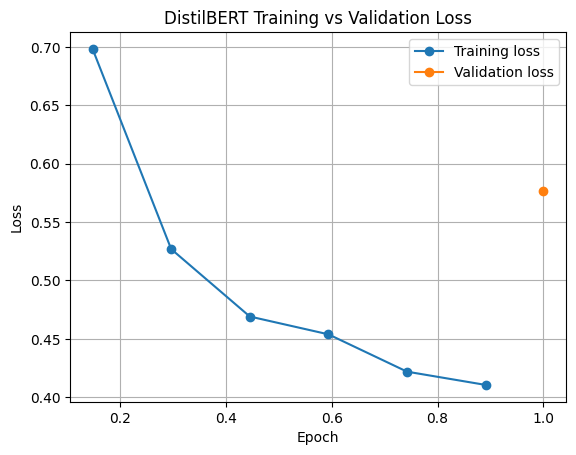

In [20]:
train_loss = history.dropna(subset=["loss"]) # DataFrame with only loss
eval_loss = history.dropna(subset=["eval_loss"]) # DataFrame with only eval_loss

# Plot the 2 DataFrames
plt.plot(train_loss["epoch"], train_loss["loss"], marker="o", label="Training loss")
plt.plot(eval_loss["epoch"], eval_loss["eval_loss"], marker="o", label="Validation loss")

# Label the Axis and provide Title
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilBERT Training vs Validation Loss")

# Add Legend and show graph
plt.legend()
plt.grid(True)
plt.show()

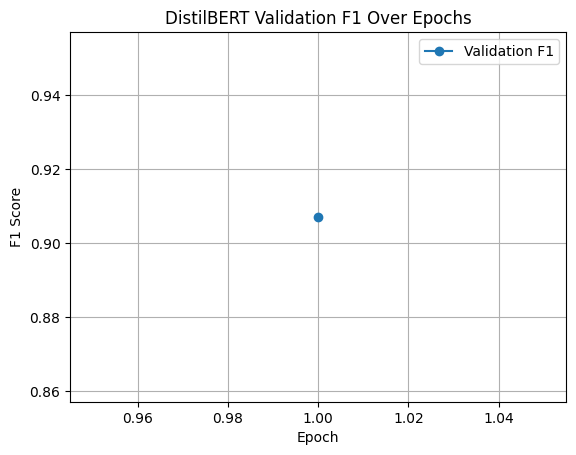

In [21]:
eval_metrics = history.dropna(subset=["eval_f1"]) # Dataframe of just eval_f1 rows

# Plot the DataFrame
plt.plot(eval_metrics["epoch"], eval_metrics["eval_f1"], marker="o", label="Validation F1")

# Label the Axis and provide Title
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("DistilBERT Validation F1 Over Epochs")

# Add Legend and show graph
plt.legend()
plt.grid(True)
plt.show()

# Model Evaluation

In [22]:
validation_results = trainer.evaluate(tokenized_sst2["validation"])

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [23]:
results = pd.DataFrame([
        {
            "Data": "Validation",
            "Loss": validation_results["eval_loss"],
            "Accuracy": validation_results["eval_accuracy"],
            "Precision": validation_results["eval_precision"],
            "Recall": validation_results["eval_recall"],
            "F1": validation_results["eval_f1"]
        }
    ])
    
print(results.to_string(index = False))

      Data     Loss  Accuracy  Precision   Recall      F1
Validation 0.576279   0.90367   0.891304 0.923423 0.90708


`model_evaluation` function:

- Takes:
  - `tokenized_test_data`: Tokenized test dataset data ready for model evaluation
  - `data_name`: String name of type of data that was provided to function

- Returns:
  - `results`: Dictionary of evaluation results including precision, recall, f1 and accuracy


This function takes tokenized test data and runs an evaluation on it from the trainer and prints and returns the results of that evaluation

In [24]:
def model_evaluation(tokenized_test_data, data_name):
    test_results = trainer.evaluate(tokenized_test_data)

    results = pd.DataFrame([
        {
            "Data": data_name,
            "Loss": test_results["eval_loss"],
            "Accuracy": test_results["eval_accuracy"],
            "Precision": test_results["eval_precision"],
            "Recall": test_results["eval_recall"],
            "F1": test_results["eval_f1"]
        }
    ])

    results = results.round(3)

    print(results.to_string(index=False))

    return results

In [25]:
clean_results = model_evaluation(tokenized_sst2["test"], "clean")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


 Data  Loss  Accuracy  Precision  Recall    F1
clean 0.351     0.942      0.949   0.947 0.948


# Save Baseline Results

In [26]:
results.to_csv("distilbert_sst2_clean.csv", index = False)

# Creating OCR Noise Substitutions

https://communityhistoryarchives.com/100-common-ocr-letter-misinterpretations/
picked some most common letters and numbers

In [27]:
ocr_confusions = {
    "a": ["o", "e"],
    "b": ["o", "h"],
    "c": ["e", "o", "0"],
    "d": ["cl", "a", "o", "3", "8"],
    "e": ["c", "a", "o", "3", "8"],
    "f": ["i", "t", "l", "1", "|"],
    "g": ["q", "B", "8", "9", "y"],
    "h": ["n", "m", "b", "ln"],
    "i": ["l", "1", "|"],
    "j": ["i", "t", "1"],
    "k": ["h", "x", "b", "|<"],
    "l": ["1", "j", "I", "|"],
    "m": ["rn", "nn", "rr", "^^", "w", "iii"],
    "n": ["r", "ri", "h", "11"],
    "o": ["0", "c", "e", "*", "$", "@"],
    "p": ["f", "b", "o", "a", "9"],
    "q": ["g", "o", "a", "cl", "@"],
    "r": ["n", "v", "i"],
    "s": ["5", "z", "$", "8"],
    "t": ["f", "+", "l"],
    "u": ["y", "n", "v"],
    "v": ["u", "y", "\\/"],
    "w": ["vv", "m", "uu"],
    "x": ["k", "+", "><"],
    "y": ["v", "g", "j", "u", "7"],
    "z": ["2", "s", ">"]
}

# Creating OCR Noisy Sentences

`add_ocr_noise` function:

- Takes:
  - `sentence`: String of sentence to go through adding noise process
  - `noise_level`: Float representing level of noise. e.g. 0.1 = 10%

- Returns:
  - `noisy_sentence`: String of the new sentence with noise added


This function takes in a sentence and a noise level and adds noise OCR style to that sentence around the noise level. Noise level is a percentage of the whole sentence which should be exchanged with incorrect values.

In [28]:
def add_ocr_noise(sentence, noise_level):
    r = random.Random(10) # Seed 10 for control
    noisy_sentence = []
    

    for character in sentence:
        character = character.lower()

        # If the character is in the ocr dictionary.
        # Then using random capped at noise level, determine a potential exchange
        if character in ocr_confusions and r.random() < noise_level:
            noisy_character = r.choice(ocr_confusions[character])
            noisy_sentence.append(noisy_character)
        else:
            noisy_sentence.append(character)

    # Join list back to complete sentence
    return "".join(noisy_sentence)

## Testing add_ocr_noise Function

In [29]:
# Test add_oct_noise function
sample_sentence = sst2["test"][3]["sentence"]

print("Original:")
print(sample_sentence)

print("\nNoisy Level 0.1:")
print(add_ocr_noise(sample_sentence, noise_level=0.1))

print("\nNoisy Level 0.3:")
print(add_ocr_noise(sample_sentence, noise_level=0.3))

print("\nNoisy Level 0.5:")
print(add_ocr_noise(sample_sentence, noise_level=0.5))

Original:
director rob marshall went out gunning to make a great one .

Noisy Level 0.1:
director rob manshall went out qunning to make a groat one .

Noisy Level 0.3:
dir3ct$r ioo maizhajl wcrit out gunhirig fo make e gnea+ ono .

Noisy Level 0.5:
d|vect$n ioo merzhajl wcrit eul gynriinq lo mabe o Br3el 0ha .


# Creating Noisy Dataset 

`create_noisy_dataset` function:

- Takes:
  - `dataset`: Dataset of sentences and labels to have noise applied to
  - `noise_function`: Function representing some type of noise application function
  - `noise_level`: Float representing level of noise. e.g. 0.1 = 10% 

- Returns:
  - `noisy_dataset`: Dataset of sentneces and labels that have had a specific level of noise applied


This function takes a dataset, a noise application function e.g. OCR and the level of noise e.g. 10% and returns the dataset with unchanged labels but with now noisy sentences

`apply_noise` function:

- Takes:
  - `dataset_row`: Single dataset row to have noise applied to

- Returns:
  - `noisy_sentence`: String of the new sentence with noise added 


This function takes a row from a dataset and applies a provided noise function to that sentence and then returns it.

In [30]:
def create_noisy_dataset(dataset, noise_function, noise_level):

    
    # Function to apply noise depending on noise_function given
    def apply_noise(dataset_row):
        noisy_sentence = noise_function(dataset_row["sentence"], noise_level)

        return {"sentence": noisy_sentence} # Reokaces original with noisy in dataset row


    noisy_dataset = dataset.map(apply_noise) # Apply apply_noise to every row in dataset

    return noisy_dataset

## Testing create_noisy_dataset Function

In [31]:
# Create noisy dataset using ocr noise and noise level of 0.2
noisy_test_dataset = create_noisy_dataset(sst2_split["test"], add_ocr_noise, 0.9)

Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

In [32]:
# Test to see if it creating noisy database function worked
i = 3
print("Original:")
print(sst2_split["test"][i]["sentence"], sst2_split["test"][i]["label"])

print("\nNoisy:")
print(noisy_test_dataset[i]["sentence"], noisy_test_dataset[i]["label"])

Original:
go hand in hand  1

Noisy:
90 lno11a ih meho  1


# Tokenize and Evaluate Function

`tokenize_and_evaluate` function:

- Takes:
  - `raw_test_data`: Test dataset data ready for model evaluation 
  - `data_name`: String name of type of data that was provided to function

- Returns:
  - `results`: Dictionary of evaluation results including precision, recall, f1 and accuracy

This function takes raw test dataset and applies tokenization to it and then performs and evaluation on it and prints and returns the results.

In [33]:
def tokenize_and_evaluate(raw_test_data, data_name):
    tokenized_test_data = tokenize_dataset(raw_test_data)
    results = model_evaluation(tokenized_test_data, data_name)
    
    return results

# Evaluating different OCR Noise Levels

In [34]:
# Generating evaluation results for different noise levels
noise_levels = [0.1, 0.2, 0.3, 0.4, 0.5]

ocr_results = []

for noise_level in noise_levels:
    noisy_test_dataset = create_noisy_dataset(sst2_split["test"], add_ocr_noise, noise_level)
    result = tokenize_and_evaluate(noisy_test_dataset, "OCR Level " + str(noise_level))

    ocr_results.append(result)

Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


         Data  Loss  Accuracy  Precision  Recall    F1
OCR Level 0.1 0.947     0.828       0.93   0.747 0.829


Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

...

         Data  Loss  Accuracy  Precision  Recall    F1
OCR Level 0.4 2.634     0.453      0.659    0.04 0.076


Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


         Data  Loss  Accuracy  Precision  Recall    F1
OCR Level 0.5 2.615     0.446      0.607   0.019 0.037


In [35]:
# Add all dataframe results into one
ocr_results_df = pd.concat(ocr_results)

print(ocr_results_df.to_string())

            Data   Loss  Accuracy  Precision  Recall     F1
0  OCR Level 0.1  0.947     0.828      0.930   0.747  0.829
0  OCR Level 0.2  2.197     0.588      0.885   0.300  0.448
0  OCR Level 0.3  2.717     0.458      0.699   0.048  0.091
0  OCR Level 0.4  2.634     0.453      0.659   0.040  0.076
0  OCR Level 0.5  2.615     0.446      0.607   0.019  0.037


In [36]:
# Extracting Accuracy and F1 from clean test results
clean_accuracy = clean_results.loc[0, "Accuracy"]
clean_f1 = clean_results.loc[0, "F1"]

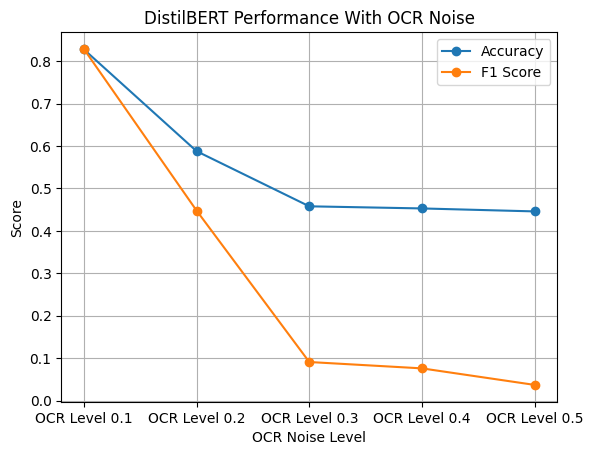

In [37]:
# Plot the DataFrame for Accuracy
plt.plot(ocr_results_df["Data"], ocr_results_df["Accuracy"], marker="o", label="Accuracy")

# Plot the DataFrame for F1
plt.plot(ocr_results_df["Data"], ocr_results_df["F1"], marker="o", label="F1 Score")

# Label the Axis and provide Title
plt.xlabel("OCR Noise Level")
plt.ylabel("Score")
plt.title("DistilBERT Performance With OCR Noise")

# Add Legend and show graph
plt.legend()
plt.grid(True)
plt.show()

# Creating Typo Noisy Data

`add_typo_noise` function:

- Takes:
  - `sentence`: String of sentence to go through adding noise process
  - `noise_level`: Float representing level of noise. e.g. 0.1 = 10%

- Returns:
  - `noisy_sentence`: String of the new sentence with noise added


This function takes in a sentence and a noise level and adds typo noise style to that sentence around the noise level. Noise level is a percentage of the whole sentence which should be exchanged with incorrect values.

In [43]:
def add_typo_noise(sentence, noise_level):
    r = random.Random(10) # Seed 10 for control
    alphabet = "abcdefghijklmnopqrstuvwxyz"
    noisy_sentence = []

    # Loop for each character in sentence
    i = 0
    while i < len(sentence):
        character = sentence[i]

        # Determine whether a deletion, insertion, replace or swap should be made
        if r.random() < noise_level and character != " ":
            choice = random.randint(1,4)
            
            if choice == 1: # Deletion
                pass
    
            elif choice == 2: # Insertion
                noisy_sentence.append(character)
                noisy_sentence.append(r.choice(alphabet))
    
            elif choice == 3: # Replace
                noisy_sentence.append(r.choice(alphabet))
    
            elif choice == 4 and i < len(sentence) - 1: # Swap
                noisy_sentence.append(sentence[i + 1])
                noisy_sentence.append(character)
                i += 1
    
            else:
                noisy_sentence.append(character)
    
        else:
            noisy_sentence.append(character)
                
        i += 1
    

    # Join list back to complete sentence
    return "".join(noisy_sentence)

## Testing add_typo_noise Function

In [50]:
sample_sentence = sst2_split["test"][11]["sentence"]

print("Original:")
print(sample_sentence)

print("\nNoise Level 0.1:")
print(add_typo_noise(sample_sentence, noise_level=0.1))

print("\nNoise Level 0.3:")
print(add_typo_noise(sample_sentence, noise_level=0.3))

print("\nNoise Level 0.5:")
print(add_typo_noise(sample_sentence, noise_level=0.5))

Original:
than a movie , which normally is expected to have characters and a storyline 

Noise Level 0.1:
than a movie e which normay is expscted jo have chaacters and a storywnie 

Noise Level 0.3:
thanp a moive  whvcfh ormaalgy is expsecteb to hasve charcterq nad a storlin 

Noise Level 0.5:
tson a mohvi ,l hch normlayj isv xepsqtcendb to hsve chraaletsr ndd av stnlikni 


# Evaluating different Typo Noise Levels

In [51]:
noise_levels = [0.1, 0.2, 0.3, 0.4, 0.5]

typo_results = []

for noise_level in noise_levels:
    noisy_test_dataset = create_noisy_dataset(sst2_split["test"], add_typo_noise, noise_level)
    result = tokenize_and_evaluate(noisy_test_dataset, "Typo Level " + str(noise_level))

    typo_results.append(result)

Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


          Data  Loss  Accuracy  Precision  Recall    F1
Typo Level 0.1  1.04     0.811      0.927   0.718 0.809


Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

...

          Data  Loss  Accuracy  Precision  Recall    F1
Typo Level 0.4 2.376     0.468      0.695   0.081 0.145


Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


          Data  Loss  Accuracy  Precision  Recall   F1
Typo Level 0.5 2.343     0.452      0.586   0.061 0.11


In [53]:
# Add all dataframe results into one
typo_results_df = pd.concat(typo_results)

print(typo_results_df.to_string())

             Data   Loss  Accuracy  Precision  Recall     F1
0  Typo Level 0.1  1.040     0.811      0.927   0.718  0.809
0  Typo Level 0.2  1.949     0.621      0.879   0.372  0.522
0  Typo Level 0.3  2.437     0.482      0.744   0.108  0.188
0  Typo Level 0.4  2.376     0.468      0.695   0.081  0.145
0  Typo Level 0.5  2.343     0.452      0.586   0.061  0.110


In [54]:
# Extracting Accuracy and F1 from clean test results
clean_accuracy = clean_results.loc[0, "Accuracy"]
clean_f1 = clean_results.loc[0, "F1"]

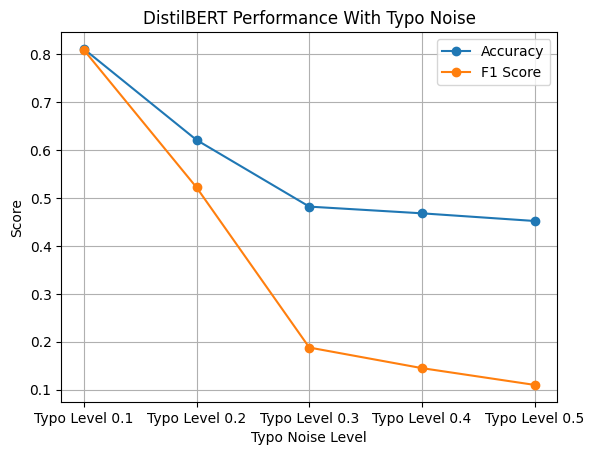

In [55]:
# Plot the DataFrame for Accuracy
plt.plot(typo_results_df["Data"], typo_results_df["Accuracy"], marker="o", label="Accuracy")

# Plot the DataFrame for F1
plt.plot(typo_results_df["Data"], typo_results_df["F1"], marker="o", label="F1 Score")

# Label the Axis and provide Title
plt.xlabel("Typo Noise Level")
plt.ylabel("Score")
plt.title("DistilBERT Performance With Typo Noise")

# Add Legend and show graph
plt.legend()
plt.grid(True)
plt.show()

# Creating Spacing Noise Fun

`add_space_noise` function:

- Takes:
  - `sentence`: String of sentence to go through adding noise process
  - `noise_level`: Float representing level of noise. e.g. 0.1 = 10%

- Returns:
  - `noisy_sentence`: String of the new sentence with noise added


This function takes in a sentence and a noise level and adds spacing noise style to that sentence around the noise level. Noise level is a percentage of the whole sentence which should be exchanged with incorrect values.

In [56]:
def add_space_noise(sentence, noise_level):
    r = random.Random(10) # Seed 10 for control
    noisy_sentence = []
    
    for character in sentence:
        # Remove a space
        if character == " " and r.random() < noise_level:
            continue

        noisy_sentence.append(character)

        # Add a space
        if character != " " and r.random() < noise_level:
            noisy_sentence.append(" ")

    
    # Join list back to complete sentence
    return "".join(noisy_sentence)

## Testing add_space_noise Function

In [64]:
sample_sentence = sst2_split["test"][3]["sentence"]

print("Original:")
print(sample_sentence)

print("\nNoise Level 0.1:")
print(add_space_noise(sample_sentence, noise_level=0.1))

print("\nNoise Level 0.3:")
print(add_space_noise(sample_sentence, noise_level=0.3))

print("\nNoise Level 0.5:")
print(add_space_noise(sample_sentence, noise_level=0.5))

Original:
go hand in hand 

Noise Level 0.1:
go hand in han d 

Noise Level 0.3:
go h andinhan d 

Noise Level 0.5:
go  h andin han d 


# Evaluating different Spacing Noise Levels

In [66]:
noise_levels = [0.1, 0.2, 0.3, 0.4, 0.5]

spacing_results = []

for noise_level in noise_levels:
    noisy_test_dataset = create_noisy_dataset(sst2_split["test"], add_space_noise, noise_level)
    result = tokenize_and_evaluate(noisy_test_dataset, "Typo Level " + str(noise_level))

    spacing_results.append(result)

          Data  Loss  Accuracy  Precision  Recall    F1
Typo Level 0.1 1.047     0.799      0.927   0.694 0.794


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


          Data  Loss  Accuracy  Precision  Recall    F1
Typo Level 0.2 1.704     0.634      0.882   0.398 0.548


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


          Data  Loss  Accuracy  Precision  Recall    F1
Typo Level 0.3 2.062     0.509      0.773   0.168 0.277


...

          Data  Loss  Accuracy  Precision  Recall    F1
Typo Level 0.4   2.0       0.5      0.762    0.15 0.251


Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

Map:   0%|          | 0/13470 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


          Data  Loss  Accuracy  Precision  Recall   F1
Typo Level 0.5 1.985     0.463      0.627   0.091 0.16


In [67]:
# Add all dataframe results into one
spacing_results_df = pd.concat(spacing_results)

print(spacing_results_df.to_string())

             Data   Loss  Accuracy  Precision  Recall     F1
0  Typo Level 0.1  1.047     0.799      0.927   0.694  0.794
0  Typo Level 0.2  1.704     0.634      0.882   0.398  0.548
0  Typo Level 0.3  2.062     0.509      0.773   0.168  0.277
0  Typo Level 0.4  2.000     0.500      0.762   0.150  0.251
0  Typo Level 0.5  1.985     0.463      0.627   0.091  0.160


In [68]:
# Extracting Accuracy and F1 from clean test results
clean_accuracy = clean_results.loc[0, "Accuracy"]
clean_f1 = clean_results.loc[0, "F1"]

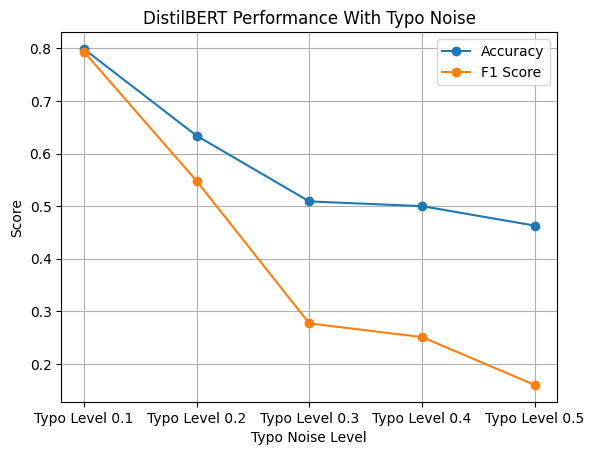

In [69]:
# Plot the DataFrame for Accuracy
plt.plot(spacing_results_df["Data"], spacing_results_df["Accuracy"], marker="o", label="Accuracy")

# Plot the DataFrame for F1
plt.plot(spacing_results_df["Data"], spacing_results_df["F1"], marker="o", label="F1 Score")

# Label the Axis and provide Title
plt.xlabel("Typo Noise Level")
plt.ylabel("Score")
plt.title("DistilBERT Performance With Typo Noise")

# Add Legend and show graph
plt.legend()
plt.grid(True)
plt.show()